# Cuestionario XAI

Realizado por Manuel Enciso Martínez

## Parte 1: Guided Integrated Gradients

Artículo de referencia: https://arxiv.org/abs/2106.09788

**`¿En qué consiste la técnica Guided Integrated Gradients?`**

Vimos en clase que el método tradicional de Integrated Gradients (IG) trazaba un camino lineal fijo entre la imagen base (baseline) y la imagen objetivo.

La versión que se explica en el artículo propone un método con un camino adaptativo que depende tanto de la imagen objetivo y de la baseline, como del modelo (siendo esto último la mejoría respecto del método tradicional IG).

Para ello, en cada paso selecciona un porcentaje de los píxeles con el menor valor absoluto de gradiente (y cuya intensidad aún no sea igual a la de la imagen objetivo), para desplazar únicamente esos píxeles hacia la intensidad de la imagen objetivo. El método finaliza cuando todos los píxeles alcanzan la intensidad de la imagen objetivo. De esta manera, el camino trazado desde una baseline hasta la imagen objetivo deja de ser necesariamente una simple línea recta.

En el artículo se explica con mayor detalle la intención de definir un camino $\gamma^{F}(\alpha)$ tal que $\gamma^{F}(0) = X^B$ (imagen de baseline) y $\gamma^{F}(1) = X^I$ (imagen objetivo), de modo que dicho camino evite las direcciones de entrada con grandes gradientes que no estén relacionados con la predicción, previniendo así el ruido en la explicación. Por tanto, se busca que se verifique:

$$ \gamma^{F\star}= \text{arg}\min_{\gamma^{F}} \mathcal{L}_{\text{ruido}}$$

Sin embargo, los autores comentan que esta aproximación puede generar un camino que se aleje demasiado de la distribución de los datos (del camino más corto). Para solucionarlo, se considera añadir a la ecuación anterior un término correspondiente a la distancia de ese camino, denotado como $\mathcal{L}_{\text{distancia}}$
distancia, ponderado por un parámetro de regularización $\lambda$, calculando así el camino óptimo:

$$ \gamma^{F\star}= \text{arg}\min_{\gamma^{F}} \mathcal{L}_{\text{ruido}} +  \lambda \mathcal{L}_{\text{distancia}}$$

Cuanto mayor sea $\lambda$, más próximo a una línea recta estará nuestro camino óptimo. De manera que, cuando $\lambda → ∞$, nos encontraríamos en el caso particular del método tradicional de IG.

**`¿Cuándo sería útil usarla?`**

El método tradicional de IG puede resaltar píxeles en la explicación final que no resultan importantes para la clasificación de la red, debido a la acumulación de ruido. En lugar de solucionar este inconveniente mediante técnicas a posteriori, Guided IG emplea un camino adaptativo directamente durante la explicación para tratar de reducir el ruido provocado por estos píxeles ruidoso.

Esto resulta de gran utilidad cuando las explicaciones obtenidas presentan mucho ruido, o en situaciones críticas como el ámbito médico, donde se requiere depurar la explicación al máximo para obtener un resultado más claro y preciso.

Para ilustrar este último caso, el artículo muestra un ejemplo  comparativo "Figura 7" usando IG y Guided IG en la detección de retinopatía diabética (diabetic retinopathy). En él se puede observar cómo los resultados de Guided IG son considerablemente menos ruidosos y se concentran de manera más precisa en un menor número de regiones (las regiones realmente importantes para la clasificación).

#### Ejemplo sobre cacatua

Guided IG se puede encontrar como método dentro del paquete Salience, al igual que el método tradicional IG.

Importaciones

In [ ]:
# Importaciones para Tarea 1
!pip install -q saliency

import torch
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

import saliency.core as saliency

Cargamos un modelo VGG16 para reconocimiento de imagenes.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.vgg16(pretrained=True).to(device)
model.eval()
print("Modelo cargado en:", device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:09<00:00, 56.4MB/s]


Modelo cargado en: cpu


Cargamos y procesamos la imagen de la cacatua

In [ ]:
# Cargamos imagen cacatua local
img_pil = Image.open('cockatoo.jpg').resize((224, 224))

# Preprocesado ImageNet estándar
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

img_tensor = transform(img_pil).unsqueeze(0).to(device)  # (1, 3, 224, 224)
img_np = np.array(img_pil, dtype=np.float32) / 255.0     # (224, 224, 3) en [0, 1]

Clase que recibe un batch de imagenes y devuelve el gradiente correspondiente, esencial para calcular los gradientes durante el camino.

In [ ]:
class_idx_str = "class_idx_str"   # clave para pasar el índice de clase

def call_model_function(images_batch, call_model_args=None, expected_keys=None):
    """
    images_batch: numpy array (N, H, W, C) en [0, 1]
    call_model_args: dict con 'class_idx_str' -> índice de clase objetivo
    """
    # Convertir de (N, H, W, C) numpy a (N, C, H, W) tensor normalizado
    images = torch.tensor(images_batch, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    mean_t = torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1).to(device)
    std_t  = torch.tensor(std,  dtype=torch.float32).view(1, 3, 1, 1).to(device)
    images = (images - mean_t) / std_t
    images.requires_grad_(True)

    output = model(images)

    # Clase objetivo: la del argmax si no se especifica
    target_class = call_model_args.get(class_idx_str) if call_model_args else None
    if target_class is None:
        target_class = output.argmax(dim=1).item()

    # Calcular gradiente respecto a la entrada
    target_score = output[:, target_class].sum()
    model.zero_grad()
    target_score.backward()

    grads = images.grad.permute(0, 2, 3, 1).detach().cpu().numpy()  # (N, H, W, C)
    return {saliency.INPUT_OUTPUT_GRADIENTS: grads}

Calculamos predicción

In [ ]:
import json

# Descargamos el fichero correspondiente con las clasificaciones
!wget -q https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json -O imagenet-simple-labels.json

with open('imagenet-simple-labels.json') as f:
    labels = json.load(f)

print(f"Cargados {len(labels)} etiquetas de ImageNet.")

Cargados 1000 etiquetas de ImageNet.


In [ ]:
with torch.no_grad():
    logits = model(img_tensor)
    probabilities = torch.softmax(logits, dim=1)
    top3_prob, top3_indices = torch.topk(probabilities, 3)

    print("Top 3 Clases Predichas:")
    for i in range(3):
        class_index = top3_indices[0][i].item()
        class_name = labels[class_index]
        probability = top3_prob[0][i].item() * 100
        print(f"  {i+1}. {class_index} ({class_name}): {probability:.4f}%")

pred_class = top3_indices[0][0].item()   # clase dominante predicha

Top 3 Clases Predichas:
  1. 89 (sulphur-crested cockatoo): 99.9943%
  2. 21 (kite): 0.0048%
  3. 88 (macaw): 0.0005%


Calculamos Guided IG

In [ ]:
guided_ig = saliency.GuidedIG()


# x_value debe ser (H, W, C) en [0, 1] — numpy float64
x_value  = img_np.astype(np.float64)
baseline = np.zeros_like(x_value)   # baseline negro

guided_ig_mask = guided_ig.GetMask(
    x_value=x_value,
    call_model_function=call_model_function,
    call_model_args={class_idx_str: pred_class},
    x_baseline=baseline,
    x_steps=200,       # pasos de integración
    fraction=0.25,     # 25% de features con gradiente más bajo se mueven por paso
    max_dist=0.02      # máxima desviación del camino lineal (0 = IG clásico)
)

print("Máscara calculada, shape:", guided_ig_mask.shape)  # (224, 224, 3)

Máscara calculada, shape: (224, 224, 3)


Visualizamos los resultados

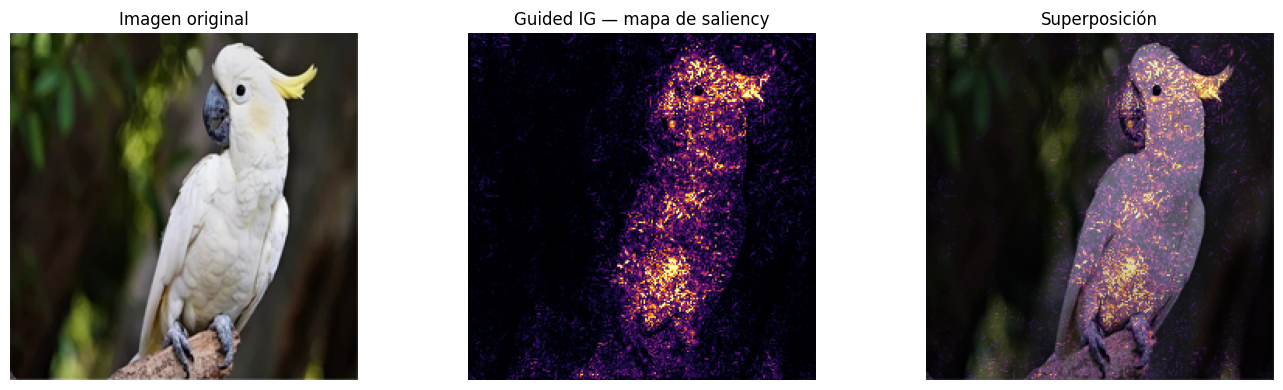

In [ ]:
# Convertir a mapa 2D (suma valor absoluto por canal)
mask_gray = saliency.VisualizeImageGrayscale(guided_ig_mask)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img_pil)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(mask_gray, cmap="inferno")
axes[1].set_title("Guided IG — mapa de saliency")
axes[1].axis("off")

# Superposición
axes[2].imshow(img_pil)
axes[2].imshow(mask_gray, cmap="inferno", alpha=0.55)
axes[2].set_title("Superposición")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Calculamos IG

In [ ]:
# Integrated Gradients
ig = saliency.IntegratedGradients()
x_value  = img_np.astype(np.float64)
baseline = np.zeros_like(x_value)   # baseline negro

ig_mask = ig.GetMask(
    x_value=x_value,
    call_model_function=call_model_function,
    call_model_args={class_idx_str: pred_class},
    x_baseline=baseline,
    x_steps=200       # único parámetro de integración
)

print("Máscara calculada, shape:", ig_mask.shape)  # (224, 224, 3)

Máscara calculada, shape: (224, 224, 3)


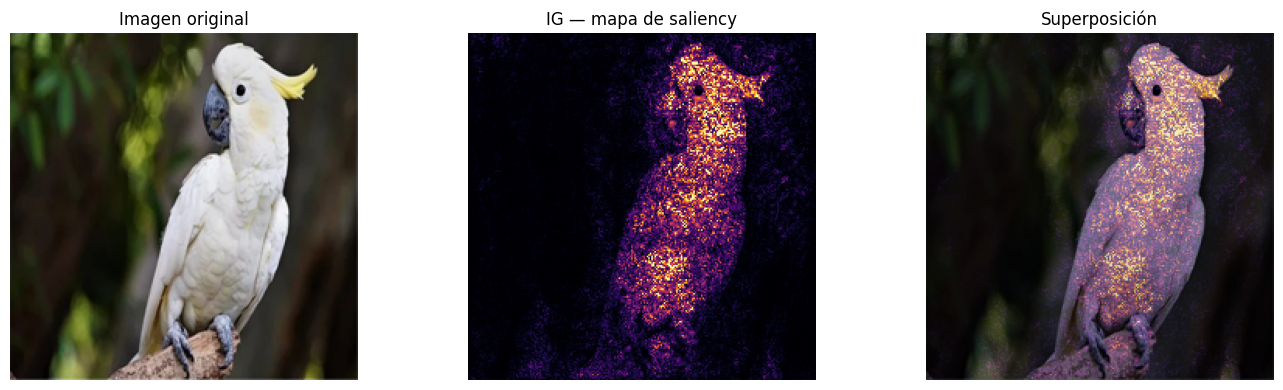

In [ ]:
# Convertir a mapa 2D (suma valor absoluto por canal)
mask_gray_ig = saliency.VisualizeImageGrayscale(ig_mask)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img_pil)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(mask_gray_ig, cmap="inferno")
axes[1].set_title("IG — mapa de saliency")
axes[1].axis("off")

# Superposición
axes[2].imshow(img_pil)
axes[2].imshow(mask_gray_ig, cmap="inferno", alpha=0.55)
axes[2].set_title("Superposición")
axes[2].axis("off")

plt.tight_layout()
plt.show()

#### Comparacion entre ambos métodos

**`Ventaja:`**

* La ventaja principal es la reducción de píxeles ruidosos presentes en la explicación. Observamos cómo la versión Guided IG para la cacatua se centra principalmente en la cresta, la cabeza y parte de las patas del pájaro, mientras que IG resalta todo lo anterior, añadiendo además como relevante la parte del cuello y el torso de forma ruidosa.

* Explicaciones más enfocadas en la predicción, evitando píxeles irrelevantes. Como muestra el caso de la "Figura 8", donde se clasifica una imagen como "baloncesto", la explicación de IG resalta varias regiones de la imagen sin permitir distinguir claramente la pelota, mientras que en Guided IG se destaca únicamente el balón de baloncesto.

**`Inconvenientes:`**

* El camino $\gamma^{F}(\alpha_{i+1})$ no se conoce hasta haber calculado el paso anterior para el camino $\gamma^{F}(\alpha_{i})$. Esto ocurre porque, como hemos comentado, en cada paso tan solo se seleccionan los píxeles cuya derivada parcial tenga el menor valor absoluto (por lo que no se conoce donde nos encontraremos en el paso futuro sin calcular el paso presente). Esto impide que se puedan paralelizar los cálculos para una sola imagen, a diferencia del caso de IG, donde ya conocemos los valores de $\gamma^{F}(\alpha_{i})$ de antemano al tratarse de una segmentación fija sobre la línea recta que une la imagen base con la imagen objetivo.

* El camino recto es el más corto en el espacio euclídeo. Al desviarnos de este camino, aunque sea parcialmente, obtenemos un recorrido de mayor longitud (por lo que para una misma longitud de segmentos en ambos métodos, se producirán un mayor número de segmentos para el método Guided IG).


Por ello, concluimos que estamos posiblemente aumentando el tiempo de cómputo a costa de ganar una mayor claridad en las explicaciones.

## Parte 2: ShapleyCAM

Artículo de referencia: https://arxiv.org/abs/2501.06261

**`Descripción detallada del método ShapleyCAM`**

El método desarrolla un marco teórico a partir de los conceptos de teoría de juegos, de manera que plantea el proceso de predicción de una red neuronal mediante un juego cooperativo. Aportando una base teórica para las explicaciones de clasificación de una red neuronal.

Mientras que Grad-CAM resultaba más heurístico, con falta de una buena base teórica. Al implementar los valores de Shapley, de teoría de juegos, se porporciona de un fundamento teórico para una mayor fiabilidad.

En este método, cada grupo de píxeles (ubicados en la misma posición espacial dentro de los diferentes mapas de activación de la red neuronal) se consideran como si fueran un jugador que colabora para lograr la predicción de la clase objetivo.

Para calcular la contribución de cada jugador (que será una aproximación del valor de Shapley), el algoritmo realiza los siguientes pasos:

* Cálculo de la utilidad: En primer lugar, se procesa la imagen para obtener la predicción y se utiliza una función de utilidad especial llamada *Residual Softmax Target-Class* (ReST). Esta función combina los valores numéricos brutos antes de la capa final (pre-softmax) con las probabilidades normalizadas (post-softmax): $$U_{\text{ReST}}= y^c + \ln(\text{softmax}(y)^c)$$

* Aproximación de segundo orden: Dado que calcular el valor exacto de Shapley requiere un tiempo computacional exponencial $\mathcal{O}(2^n)$, el método aproxima la función de utilidad utilizando una expansión de Taylor de segundo orden.

* Cálculo de Gradientes y Matriz Hessiana: Se realiza una propagación hacia atrás (backward pass) para calcular cómo cambian las predicciones al modificar la imagen. Calcula el gradiente y el producto de la matriz Hessiana (derivada de segundo orden) respecto a los mapas de activación.

* Generación del mapa de calor: Se ponderan los mapas de activación originales utilizando una fórmula matemática que resta la mitad del impacto del valor Hessiano al gradiente. Al final, se suman linealmente y se les aplica una función ReLU exterior para descartar los píxeles que tienen una contribución negativa en la predicción.

**`Diferencias principales con Grad-CAM`**

ShapleyCAM incorpora derivadas de segundo orden (la matriz Hessiana) basadas en la aproximación de segundo orden de la función de utilidad, lo que permite capturar interacciones más complejas y generar explicaciones más precisas y confiables.

Grad-CAM genera su mapa utilizando únicamente los puntajes pre-softmax. El gran problema de esto es que, si se le pide que explique la predicción de un objeto, también puede destacar regiones de la imagen que pertenecen a otras clases (por ejemplo, resaltar regiones de un perro cuando trata de justificar la predicción de un gato).

ShapleyCAM soluciona esto usando la utilidad ReST, la cual contrarresta este efecto restando los mapas de otras clases para enfocar la explicación exclusivamente en la clase objetivo.

**`Ventajas de usar los Valores de Shapley`**

El uso de los valores de Shapley, como hemos comentado, convierte el método más fiable. Debido a que los valores de Shapley, proporcionan de cuatro axiomas de equidad:

* Jugador ficticio: Garantiza que si un píxel no aporta absolutamente ninguna información útil a la clasificación en ningún escenario, su contribución final será exactamente cero.

* Simetría: Si dos píxeles aportan exactamente el mismo valor a la red neuronal, ambas recibirán exactamente el mismo valor de contribución.

* Eficiencia: Asegura que la probabilidad de la predicción total se distribuya completamente entre todas las características de la imagen.

* Linealidad: Permite que las explicaciones puedan separarse y sumarse de manera predecible.

Lo cual hace que sea más fiable e interpretable los resultados obtenidos en los mapas de calor.

#### Ejemplo sobre cacatua

ShapleyCAM método importado de la librería grad-cam

Importaciones

In [ ]:
# Importaciones para Tarea 2

!pip install -q grad-cam

import torch
import torchvision
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from pytorch_grad_cam import ShapleyCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputReST

Cargamos un modelo VGG16 para reconocimiento de imagenes.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.vgg16(pretrained=True).to(device)
model.eval()

# Capa objetivo: última convolucional antes del pooling global
# En VGG16 es model.features[-3] (Conv2d antes del MaxPool final)
target_layers = [model.features[-3]]

print("Modelo cargado en:", device)
print("Capa objetivo:", target_layers[0])

Modelo cargado en: cpu
Capa objetivo: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


Cargamos y procesamos la imagen de la cacatua

In [ ]:
# Cargamos imagen cacatua local
img_pil = Image.open('cockatoo.jpeg').resize((224, 224))

# Preprocesado ImageNet estándar
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

img_tensor = transform(img_pil).unsqueeze(0).to(device)  # (1, 3, 224, 224)
img_np = np.array(img_pil, dtype=np.float32) / 255.0     # (224, 224, 3) en [0, 1]

Calculamos predicción

In [ ]:
import json

# Descargamos el fichero correspondiente con las clasificaciones
!wget -q https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json -O imagenet-simple-labels.json

with open('imagenet-simple-labels.json') as f:
    labels = json.load(f)

print(f"Cargados {len(labels)} etiquetas de ImageNet.")

Cargados 1000 etiquetas de ImageNet.


In [ ]:
with torch.no_grad():
    logits = model(img_tensor)
    probabilities = torch.softmax(logits, dim=1)
    top3_prob, top3_indices = torch.topk(probabilities, 3)

    print("Top 3 Clases Predichas:")
    for i in range(3):
        class_index = top3_indices[0][i].item()
        class_name = labels[class_index]
        probability = top3_prob[0][i].item() * 100
        print(f"  {i+1}. {class_index} ({class_name}): {probability:.4f}%")

pred_class = top3_indices[0][0].item()   # clase dominante predicha

Top 3 Clases Predichas:
  1. 89 (sulphur-crested cockatoo): 99.9943%
  2. 21 (kite): 0.0042%
  3. 88 (macaw): 0.0008%


Calcular ShapleyCAM con función ReST

In [ ]:
# ReST = yc + ln(softmax(y)c) — función de utilidad propuesta en el paper
# Combina las ventajas del pre-softmax y post-softmax evitando gradient vanishing
targets = [ClassifierOutputReST(pred_class)]

with ShapleyCAM(model=model, target_layers=target_layers) as cam:
    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=targets
    )

# grayscale_cam tiene shape (1, 224, 224); tomamos la primera imagen
grayscale_cam = grayscale_cam[0]
print("Mapa ShapleyCAM calculado, shape:", grayscale_cam.shape)

Mapa ShapleyCAM calculado, shape: (224, 224)


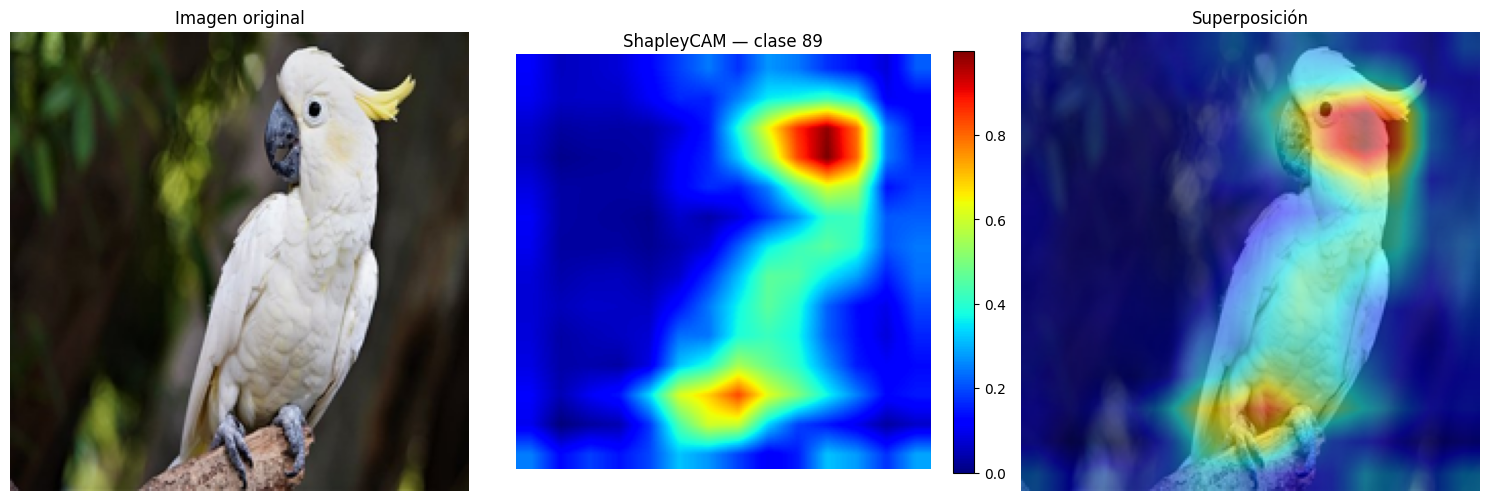

In [ ]:
# Superponer el heatmap sobre la imagen original
visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_pil)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(grayscale_cam, cmap="jet")
axes[1].set_title(f"ShapleyCAM — clase {pred_class}")
axes[1].colorbar = plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)
axes[1].axis("off")

axes[2].imshow(visualization)
axes[2].set_title("Superposición")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Parte 3: Manipulación de explicaciones

Artículo de referencia: https://arxiv.org/pdf/1906.07983

**`Descripción teórica`**

#### **Introducción**
En este artículo se presenta que, verificandose unas ciertas condiciones iniciales, somos capaces de alterar el mapa de explicabilidad arbitrariamente de una imagen manteniendo en todo momento la clasificación final constante, tan solo aplicando modificaciones *a penas perceptibles* al ojo humano en la imagen original. Ha diferencia de otros métodos que logran tal resultados similares, el método presentado a continuación no requiere modificar los pesos de la red neuronal.

Consideremos una red neuronal $g:\mathbb{R}^d\rightarrow \mathbb{R}^k$ con activaciones ReLU para la clasificación de imagenes $x\in\mathbb{R}^d$ en $K$ categorías, con predicción de salida $k = \text{argmax}_ig(x)_i$. En la práctica, nos resultará útil considerar que la red neuronal nos devuelve únicamente la predicción de salida $k$, por lo que reducimos la notación a $g:\mathbb{R}^d\rightarrow \mathbb{R}$.

Vamos a denotar por $h:\mathbb{R}^d\rightarrow \mathbb{R}^d$ al mapa de explicabilidad, que recibe como entrada una imagen $x\in\mathbb{R}^d$ y devuelve un vector de la misma dimensión cuyas componentes codifican la relevancia de cada pixel respecto de la clasificación $k$ de la red neuronal.

#### **Planteamiento del método**

Como hemos comentado anteriormente, nuestro objetivo es cambiar $h(x)$ mediante pequeñas perturbacines en $x$.

Denotaremos por $h^t\in \mathbb{R}^d$ al mapa de explicabilidad adversario objetivo. El cual queremos obtener al aplicarle alguno de los metodos de explicabilidad a la imagen $x\in\mathbb{R}^d$.

Para ello, nuestro objetivo es calcular la imagen adversaría $x_\text{adv} = x + \delta x$ (imagen original con cierta perturbación), de modo que $h(x_\text{adv}) \approx h^t$ y que $g(x_\text{adv}) \approx g(x)$ para que la clasificación se mantenga constante. Para ello, nuestra función de pérdida a optimizar se puede definir como:

$$ \mathcal{L}(x_\text{adv}\mid h^t,x) = \|h(x_\text{adv}) - h^t\|^2 + \gamma \|g(x_\text{adv}) - g(x)\|^2$$

Podemos optimizar la función de pérdida, usando la técnica del descenso por el gradiente respecto de $x_\text{adv}$. Obteniendo en cada iteración un valor $x_\text{adv}\in \mathbb{R}^d$ que minimiza la ecuación anterior, al cual debemos de ajustar para obtener una representación válida de imagen.

El primer término de la ecuación anterior corresponde con la pérdida de explicabilidad entre el mapa objetivo y el mapa adversario, de manera que el mapa de explicabilidad $h(x_\text{adv})$ se aproxime al mapa objetivo $h^t$. El segundo término corresponde con la pérdida de clasificación de la imagen adversaria $g(x_\text{adv})$ respecto de la original $g(x)$, de modo que la imagen adversaria mantenga la clasificación de la imagen original, controlada mediante un hiperparámetro $\gamma \in \mathbb{R}^+$.

#### **Suaviazo de la explicación**

El inconveniente principal de usar la función de activación ReLU en la red neuronal. Es que para métodos de explicabilidad basados en el gradiente, al calcular el gradiente al primer término respecto de $x_{\text{adv}}$ obtenemos que:

$$ \partial x_\text{adv} ||h(x_\text{adv}) - h^t ||^2 \propto \frac{\partial }{\partial x_\text{adv}}h(x_\text{adv}) = \frac{\partial^2 g(x_\text{adv})}{\partial x_\text{adv}^2} \propto \text{ReLU}^{\prime \prime} = 0$$

Por este motivo, para métodos de explicabilidad basados en el gradiente, vamos a tener reemplazar la función de activación ReLU por otra aproximación que tenga segunda derivada no nula. Una de las funciones de aproximación de la ReLU, siguiendo el artículo, podría ser la función:

$$ \text{softplus}_\beta(x) = \frac{1}{\beta}\log(1+e^{\beta x}), \qquad \text{para }\beta>0$$

#### **Problema de la geometría**

En el artículo profundizan al detalle en la geometría de la red neuronal. Obteniendo una relación entre la curvatura principal y la sensibilidad de la explicación. Obteniendo como resultado un valor de cota superior sobre el cambio máximo que se puede producir en el mapa de explicabilidad $h(x)$ mientras nos movemos ligeramente en $S = \{p\in\mathbb{R}\mid g(p)=c\}$ (hiperplano que contiene todas las imagenes con la misma clasificación que la imagen original $x$), el resultado del **teorema** es el siguiente:

$$ \|h(p) - h(p_0)\| \leq |\lambda_{\max}| \, d_g(p, p_0) \leq \beta C \, d_g(p, p_0)$$

Este teorema nos motiva a pensar que, para una red con activaciones activaciones ReLU, para dos imagenes en $S$ están unidas por funciones linealmente a trozos (pueden haber picos, cambios drásticos de curvatura). Al reducir el parámetro $\beta$ en la función de suavizado, obtenemos un mayor suavizado, logrando reducir el cambio de la curvatura maximal de las imagenes.

Como nos estamos moviendo en el hiperplano $S$, resulta que dos imagenes que son similares (distancia euclídea pequeña) pueden estar conectadas mediantes un camino con una distancia geodésica mucho mayor y por tanto explicación drasticamente diferente. Reducir el valor del parámetro $\beta$ reduce la curvatura máximal, por lo que reducimos el camino geodesico de ambas imagenes obteniendo una explicación mucho más robusta.


#### **Resultados del suavizado visualmente**

En esta ilustración se puede observar el problema sobre la geometría que hace referencia el articulo. Una red con activaciones ReLU tiene segmentos linelamente a trozos que conectan dos imagenes proximas (visualmente similares) cuyos gradientes (mapas de explicación) apuntan a direcciones ortogonales.

Pero una vez aplicada la función de suvidazo, representado ahora por el segmento de color rojo, se produce una regularización en la curvatura de la red, de manera que las dos imagenes próximas si tienen gradientes similares (y por tanto explicaciones similares).

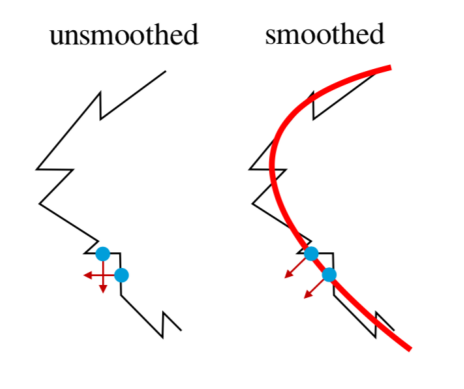

Esto se puede ver también de la siguiente manera. Si queremos obtener una explicación adversaria $h^t$ fija, para una imagen $x$ mediante pequeñas manipulaciones, hasta obtener una imagen alterada adversaria $x_{\text{adv}}$. Mediante la intuición proporcionada por el teorema anterior que relaciona el suavizado $\beta$ y la distancia geodésica $d_g(x,x_{\text{adv}})$, tenemos que:
* **Para $\beta → ∞$**: La distancia entre $x$ y $x_{\text{adv}}$ es menor, debido a que al ser $S$ (segmentos en negro) formada por segmentos linealmente a trozos, en una región local centrada en $x$ existen grandes cambios de curvatura y por tanto es más fácil encontrar una imagen $x_{\text{adv}}$ cuya explicación coincida (o se aproxime) a $h^t$.
* **Para $\beta = 0.8$**: La distancia entre $x$ y $x_{\text{adv}}$ es mayor, ya que al regularizar la superficie $S$ (segmentos en rojo), en una región local cerca de $x$ los gradientes son parecidos y por tanto debemos movermos a una distancia mayor para encontrar una imagen $x_{\text{adv}}$ cuya explicación coincida (o se aproxime) a $h^t$.

Concluimos que el suavizado de las explicaciones $\beta = 0.8$, dificulta los ataques. Forzar al modelo a producir un mapa de explicabilidad objetivo fijo $h^t$, requiere calcular una imagen adversaria $x_{\text{adv}} = x + \delta x$ para una perturbación $| \delta x|$ mucho mayor en comparación con un escenario sin suavizado.

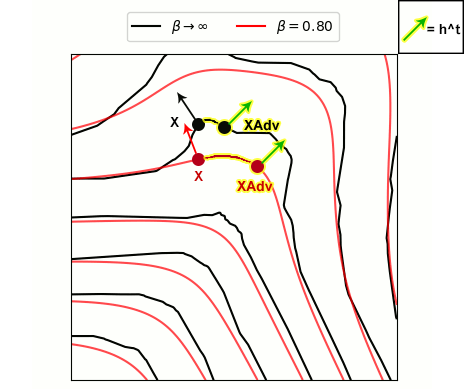

#### Ejemplo sobre cacatua

Vamos a clonar el repositorio del paper original: https://github.com/pankessel/adv_explanation_ref.git

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Clona el repo en Drive
REPO_DIR = "/content/drive/MyDrive/adv_explanation_ref/adv_explanation_ref" #Esta es la direccion que tengo yo, cambiar a la que se use

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/pankessel/adv_explanation_ref.git "{REPO_DIR}"
else:
    print("Repo ya existe en Drive, saltando clonación.")

Mounted at /content/drive
Repo ya existe en Drive, saltando clonación.


In [ ]:
import sys

# Apuntar a la carpeta src del repo para poder importar nn.*
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

# Instalar dependencias si hace falta
!pip install -q torch torchvision

Vamos a implementar el codigo run_attack.py como función de python para poder ejecutarla en el cuaderno.

In [ ]:
import torch
import torchvision
import torch.nn.functional as F
import numpy as np

# Importamos los módulos del repo originales
from nn.enums import ExplainingMethod
from nn.networks import ExplainableNet
from nn.utils import get_expl, plot_overview, clamp, load_image, make_dir


def get_beta(i, num_iter):
    start_beta, end_beta = 10.0, 100.0
    return start_beta * (end_beta / start_beta) ** (i / num_iter)


def run_attack(
    num_iter=1500,
    img=f"{REPO_DIR}/data/collie4.jpeg",
    target_img=f"{REPO_DIR}/data/tiger_cat.jpeg",
    lr=0.0002,
    cuda=False,
    output_dir=f"{REPO_DIR}/output/",
    beta_growth=False,
    prefactors=(1e11, 1e6),
    method="lrp",
):
    device = torch.device("cuda" if cuda and torch.cuda.is_available() else "cpu")
    method_enum = getattr(ExplainingMethod, method)

    data_mean = np.array([0.485, 0.456, 0.406])
    data_std  = np.array([0.229, 0.224, 0.225])

    vgg_model = torchvision.models.vgg16(pretrained=True)
    model = ExplainableNet(
        vgg_model,
        data_mean=data_mean,
        data_std=data_std,
        beta=1000 if beta_growth else None,
    )
    if method_enum == ExplainingMethod.pattern_attribution:
        model.load_state_dict(
            torch.load(f"{REPO_DIR}/models/model_vgg16_pattern_small.pth"),
            strict=False
        )
    model = model.eval().to(device)

    x        = load_image(data_mean, data_std, device, img)
    x_target = load_image(data_mean, data_std, device, target_img)
    x_adv    = x.clone().detach().requires_grad_()

    org_expl, org_acc, org_idx = get_expl(model, x, method_enum)
    org_expl = org_expl.detach().cpu()
    target_expl, _, _ = get_expl(model, x_target, method_enum)
    target_expl = target_expl.detach()

    optimizer = torch.optim.Adam([x_adv], lr=lr)

    for i in range(num_iter):
        if beta_growth:
            model.change_beta(get_beta(i, num_iter))

        optimizer.zero_grad()

        adv_expl, adv_acc, class_idx = get_expl(
            model, x_adv, method_enum, desired_index=org_idx
        )
        loss_expl   = F.mse_loss(adv_expl, target_expl)
        loss_output = F.mse_loss(adv_acc, org_acc.detach())
        total_loss  = prefactors[0] * loss_expl + prefactors[1] * loss_output

        total_loss.backward()
        optimizer.step()
        x_adv.data = clamp(x_adv.data, data_mean, data_std)

        print(f"Iter {i}: Loss={total_loss.item():.4f} | Expl={loss_expl.item():.12f} | Out={loss_output.item():.12f}")

    model.change_beta(None)
    adv_expl, adv_acc, _ = get_expl(model, x_adv, method_enum)

    # Guarda los resultados directamente en Drive
    out = make_dir(output_dir)
    plot_overview(
        [x_target, x, x_adv],
        [target_expl, org_expl, adv_expl],
        data_mean, data_std,
        filename=f"{out}overview_{method}.png"
    )
    torch.save(x_adv, f"{out}x_{method}.pth")
    print(f" Resultados guardados en: {out}")

    return {"x_adv": x_adv.detach().cpu(), "adv_expl": adv_expl.detach().cpu()}

no display found. Using non-interactive Agg backend


Ataque usando el método del gradiente.

In [ ]:
# Con el codigo anterior somos capaces de ejecutar la linea de codigo siguiente (que tendría que ejecutarse en local):
#
# python src/run_attack.py --num_iter 1000 --img tiger_cat.jpg --target_img collie4.jpg --beta_growth --method gradient

# Por una funcion run_attack(parámetros...), para google colab.

res = run_attack(
    num_iter=1000,
    img=f"{REPO_DIR}/data/cockatoo.jpg",       # Imagen original (el loro de cresta, descargado anteriormente en la carpeta /data)
    target_img=f"{REPO_DIR}/data/tiger_cat.jpeg",  # Imagen adversaria para mapa de calor
    beta_growth=True,
    method="gradient",
    cuda=True,   # False si no usas GPU en Colab
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 72.6MB/s]


Iter 0: Loss=72.7575 | Expl=0.000000000728 | Out=0.000000000000
Iter 1: Loss=68.8923 | Expl=0.000000000689 | Out=0.000000000000
Iter 2: Loss=65.8855 | Expl=0.000000000659 | Out=0.000000000000
Iter 3: Loss=63.4536 | Expl=0.000000000635 | Out=0.000000000000
Iter 4: Loss=61.3583 | Expl=0.000000000614 | Out=0.000000000000
Iter 5: Loss=59.6146 | Expl=0.000000000596 | Out=0.000000000000
Iter 6: Loss=57.9383 | Expl=0.000000000579 | Out=0.000000000000
Iter 7: Loss=56.5173 | Expl=0.000000000565 | Out=0.000000000000
Iter 8: Loss=55.3212 | Expl=0.000000000553 | Out=0.000000000000
Iter 9: Loss=54.2580 | Expl=0.000000000543 | Out=0.000000000000
Iter 10: Loss=53.2730 | Expl=0.000000000533 | Out=0.000000000000
Iter 11: Loss=52.3931 | Expl=0.000000000524 | Out=0.000000000000
Iter 12: Loss=51.5332 | Expl=0.000000000515 | Out=0.000000000000
Iter 13: Loss=50.7298 | Expl=0.000000000507 | Out=0.000000000000
Iter 14: Loss=49.9162 | Expl=0.000000000499 | Out=0.000000000000
Iter 15: Loss=49.2522 | Expl=0.0000

Visualizamos el ataque.

Displaying image from: /content/drive/MyDrive/adv_explanation_ref/adv_explanation_ref/output/overview_gradient.png


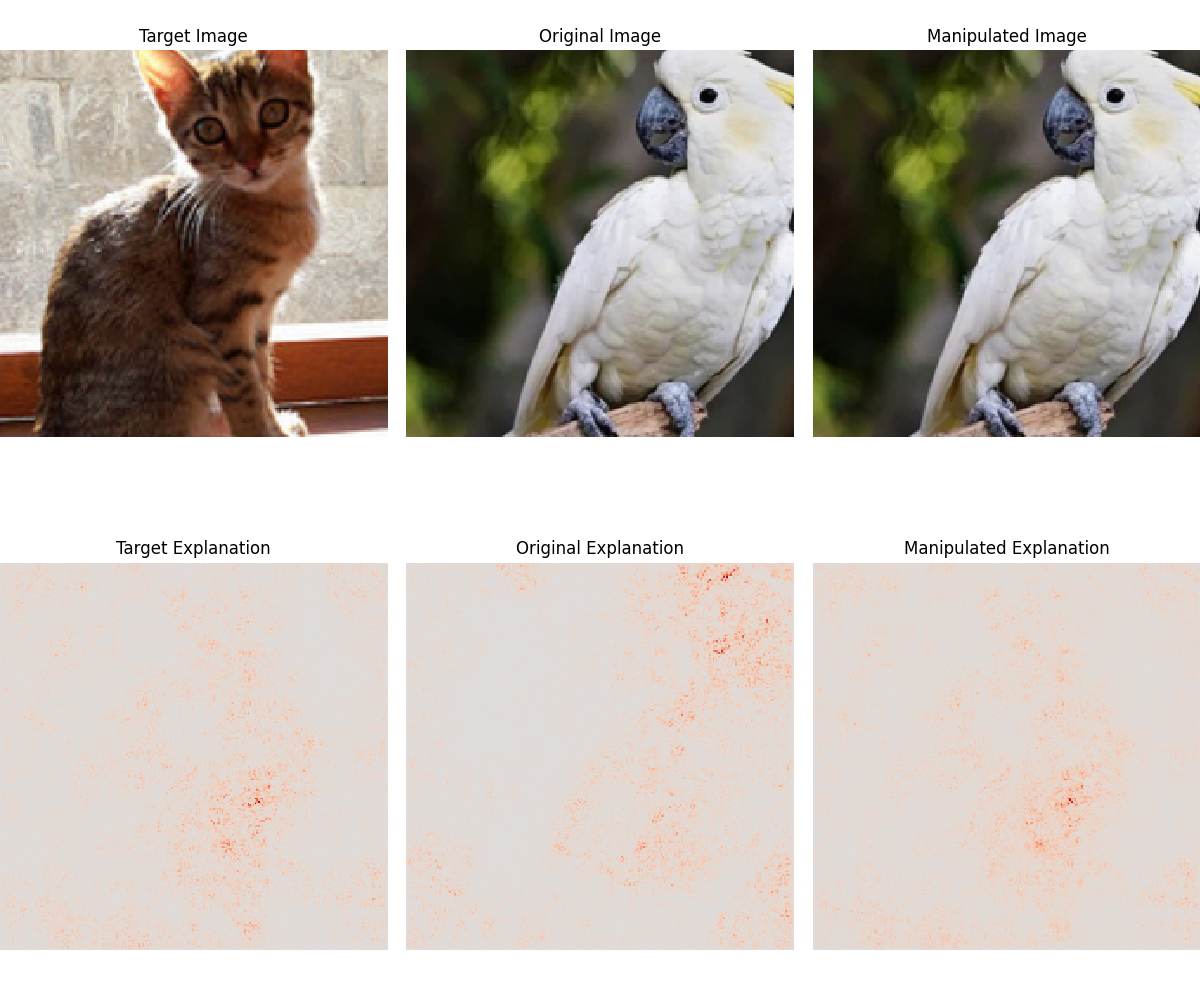

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

image_path = '/content/drive/MyDrive/MULCIA_SAAA/adv_explanation_ref/output/overview_gradient.png'


print(f"Displaying image from: {image_path}")
display(Image(filename=image_path))



Ataque usando el método del LRP.

In [ ]:
res = run_attack(
    num_iter=1000,
    img=f"{REPO_DIR}/data/cockatoo.jpg",       # Imagen original
    target_img=f"{REPO_DIR}/data/tiger_cat.jpeg",  # Imagen adversaria para mapa de calor
    beta_growth=True,
    method="lrp",
    cuda=True,   # False si no usas GPU en Colab
)

Iter 0: Loss=145.9498 | Expl=0.000000001459 | Out=0.000000000000
Iter 1: Loss=142.1296 | Expl=0.000000001421 | Out=0.000000000000
Iter 2: Loss=138.5174 | Expl=0.000000001385 | Out=0.000000000000
Iter 3: Loss=135.0849 | Expl=0.000000001351 | Out=0.000000000000
Iter 4: Loss=131.8468 | Expl=0.000000001318 | Out=0.000000000000
Iter 5: Loss=128.8277 | Expl=0.000000001288 | Out=0.000000000000
Iter 6: Loss=125.8380 | Expl=0.000000001258 | Out=0.000000000000
Iter 7: Loss=123.1116 | Expl=0.000000001231 | Out=0.000000000000
Iter 8: Loss=120.3423 | Expl=0.000000001203 | Out=0.000000000000
Iter 9: Loss=117.9190 | Expl=0.000000001179 | Out=0.000000000000
Iter 10: Loss=115.5949 | Expl=0.000000001156 | Out=0.000000000000
Iter 11: Loss=113.3917 | Expl=0.000000001134 | Out=0.000000000000
Iter 12: Loss=111.1178 | Expl=0.000000001111 | Out=0.000000000000
Iter 13: Loss=109.2053 | Expl=0.000000001092 | Out=0.000000000000
Iter 14: Loss=107.4026 | Expl=0.000000001074 | Out=0.000000000000
Iter 15: Loss=105.73

Visualizamos el ataque.

Displaying image from: /content/drive/MyDrive/adv_explanation_ref/adv_explanation_ref/output/overview_lrp.png


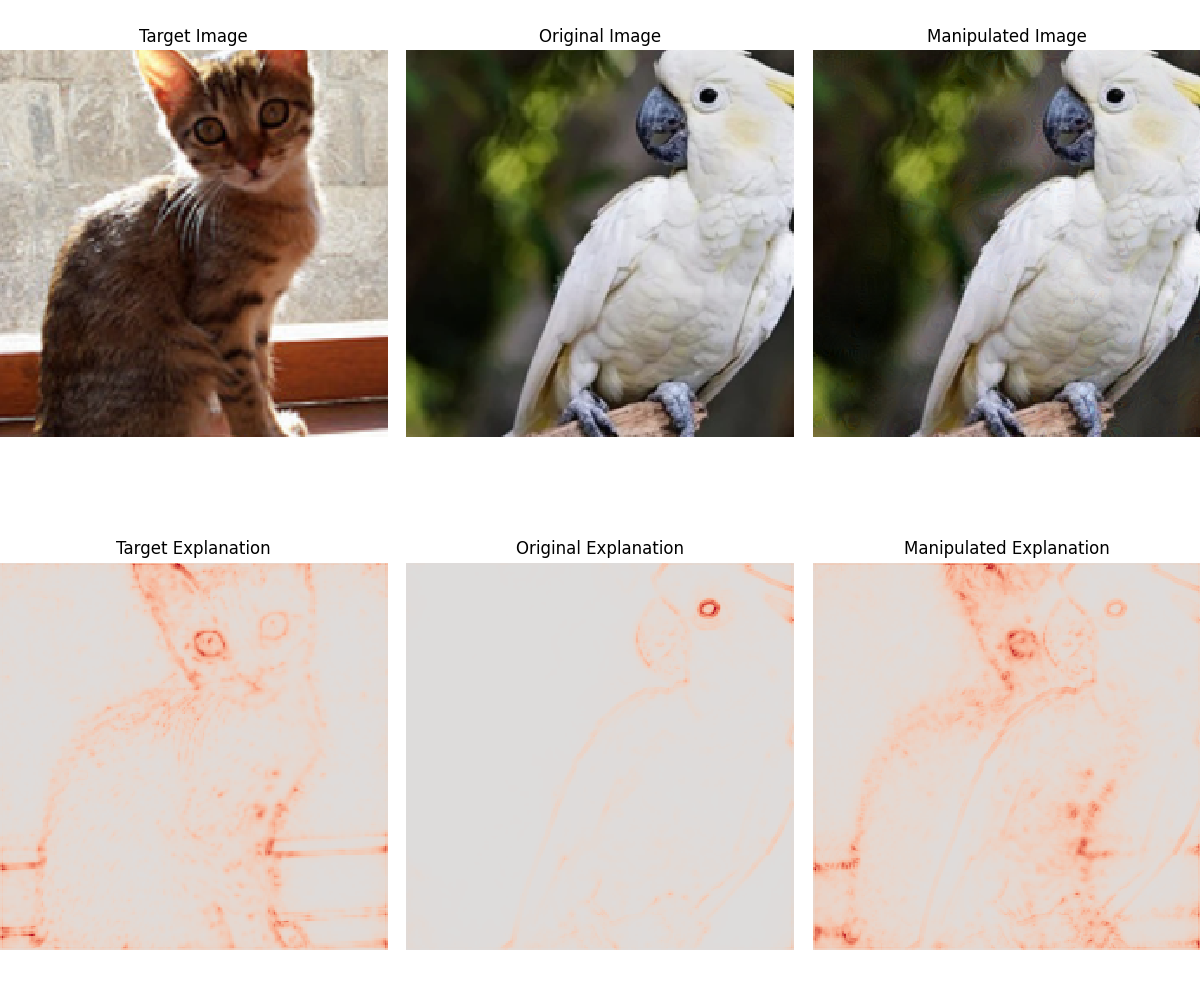

In [ ]:
image_path = '/content/drive/MyDrive/adv_explanation_ref/adv_explanation_ref/output/overview_lrp.png'


print(f"Displaying image from: {image_path}")
display(Image(filename=image_path))



Observamos que el método del gradiente obtiene mapas de explicabilidad más ruidoso, y por que resulta *más sencillo de atacar* (menos píxeles hay que alterar). En cambio, el mapa de explicabilidad producido por el método LRP está más detallado (regiones de pixeles cercanas con grandes valores explicativos), destacando claramente la figura del gato y cacatua, resultando en un ataque más complicado.

Aunque si nos fijamos en las métricas, aplicando $\text{prefactors}=(1e11, 1e6)$, resulta que:
* **Gradiente**: `Iter 999: Loss=12.4949 | Expl=0.000000000125 | Out=0.000000000000`
* **LRP**: `Iter 999: Loss=9.2975 | Expl=0.000000000093 | Out=0.000000004401`

Resulta que la pérdida de explicación (diferencia entre mapa de explicación objetivo $h^t$ y $h(x_{\text{adv}})$) es menor en **LRP** que en **Gradiente**, aunque visualmente parezca al contrario. Esto se debe a que han usado la métrica del valor medio al cuadrado, cuando igual hubiera sido más conveniente usar SSIM para similitud visual en imagenes para el ojo humano.

---